In [1]:
#Import Libraries
import pandas as pd
import duckdb
from pathlib import Path

In [4]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "Notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

carbon_path = PROCESSED_DIR / "carbon_intensity_last_7_complete_days.csv"
price_path = PROCESSED_DIR / "elexon_system_prices_last_7_complete_days.csv"

print(carbon_path.exists(), carbon_path)
print(price_path.exists(), price_path)

True C:\Users\iniob\Toni_projects\Hydrogen Project\Data\Processed\carbon_intensity_last_7_complete_days.csv
True C:\Users\iniob\Toni_projects\Hydrogen Project\Data\Processed\elexon_system_prices_last_7_complete_days.csv


In [5]:
#Read file paths
carbon_df = pd.read_csv(carbon_path)
price_df = pd.read_csv(price_path)

carbon_df.head(),price_df.head()

(  date_requested                   from_utc                     to_utc  \
 0     2026-06-22  2026-06-21 23:00:00+00:00  2026-06-21 23:30:00+00:00   
 1     2026-06-22  2026-06-21 23:30:00+00:00  2026-06-22 00:00:00+00:00   
 2     2026-06-22  2026-06-22 00:00:00+00:00  2026-06-22 00:30:00+00:00   
 3     2026-06-22  2026-06-22 00:30:00+00:00  2026-06-22 01:00:00+00:00   
 4     2026-06-22  2026-06-22 01:00:00+00:00  2026-06-22 01:30:00+00:00   
 
    forecast_gco2_per_kwh  actual_gco2_per_kwh index  \
 0                    193                  189  high   
 1                    188                  187  high   
 2                    196                  182  high   
 3                    190                  179  high   
 4                    189                  179  high   
 
                      from_uk                      to_uk     date_uk  hour_uk  \
 0  2026-06-22 00:00:00+01:00  2026-06-22 00:30:00+01:00  2026-06-22        0   
 1  2026-06-22 00:30:00+01:00  2026-06-22 01:00:

In [7]:
carbon_df["from_uk"] = (
    pd.to_datetime(carbon_df["from_uk"], utc=True)
    .dt.tz_convert("Europe/London")
)

carbon_df["settlement_date"] = carbon_df["from_uk"].dt.strftime("%Y-%m-%d")

carbon_df["settlement_period"] = (
    carbon_df["from_uk"].dt.hour * 2
    + (carbon_df["from_uk"].dt.minute // 30)
    + 1
)

carbon_df[["from_uk", "settlement_date", "settlement_period", "forecast_gco2_per_kwh", "actual_gco2_per_kwh"]].head()

,from_uk,settlement_date,settlement_period,forecast_gco2_per_kwh,actual_gco2_per_kwh
0,2026-06-22 00:00:00+01:00,2026-06-22,1,193,189
1,2026-06-22 00:30:00+01:00,2026-06-22,2,188,187
2,2026-06-22 01:00:00+01:00,2026-06-22,3,196,182
3,2026-06-22 01:30:00+01:00,2026-06-22,4,190,179
4,2026-06-22 02:00:00+01:00,2026-06-22,5,189,179


In [8]:
carbon_df['from_uk_naive'] = carbon_df['from_uk'].dt.tz_localize(None)
carbon_df['from_uk_naive'].head()

0   2026-06-22 00:00:00
1   2026-06-22 00:30:00
2   2026-06-22 01:00:00
3   2026-06-22 01:30:00
4   2026-06-22 02:00:00
Name: from_uk_naive, dtype: datetime64[us]

In [16]:
price_df.dtypes #Ensure both databases using same datatypes

settlement_date                             str
settlement_period                         int64
system_buy_price_gbp_per_mwh            float64
system_sell_price_gbp_per_mwh           float64
from_uk_naive                    datetime64[us]
to_uk_naive                                 str
price_gbp_per_mwh                       float64
dtype: object

In [17]:
carbon_df.dtypes

date_requested                                     str
from_utc                                           str
to_utc                                             str
forecast_gco2_per_kwh                            int64
actual_gco2_per_kwh                              int64
index                                              str
from_uk                  datetime64[us, Europe/London]
to_uk                                              str
date_uk                                            str
hour_uk                                          int64
time_uk                                            str
settlement_date                                    str
settlement_period                                int32
from_uk_naive                           datetime64[us]
dtype: object

In [21]:
#Going to clean up datatypes
price_df['settlement_date'] = pd.to_datetime(price_df['settlement_date'])
carbon_df['settlement_date'] = pd.to_datetime(carbon_df['settlement_date'])

price_df['from_uk_naive'] = pd.to_datetime(price_df['from_uk_naive']).astype('datetime64[us]')

In [22]:
price_df.dtypes

settlement_date                  datetime64[us]
settlement_period                         int64
system_buy_price_gbp_per_mwh            float64
system_sell_price_gbp_per_mwh           float64
from_uk_naive                    datetime64[us]
to_uk_naive                                 str
price_gbp_per_mwh                       float64
dtype: object

In [24]:
#Use duckdb to join
import duckdb

In [26]:
DB_PATH = PROCESSED_DIR / 'hydrogen_project.duckdb'

con = duckdb.connect(DB_PATH)

con.register('carbon_df', carbon_df)
con.register('price_df', price_df)

In [28]:
con.execute('''
CREATE OR REPLACE TABLE carbon_intensity AS
SELECT
    settlement_date,
    settlement_period,
    from_uk_naive,
    forecast_gco2_per_kwh,
    actual_gco2_per_kwh,
    index
FROM carbon_df
''')

In [30]:
con.execute("""
CREATE OR REPLACE TABLE electricity_prices AS
SELECT
    settlement_date,
    settlement_period,
    from_uk_naive,
    price_gbp_per_mwh,
FROM price_df
""")

In [31]:
con.execute('SHOW TABLES').df()

,name
0,carbon_df
1,carbon_intensity
2,electricity_prices
3,price_df


In [32]:
con.execute('''
CREATE OR REPLACE TABLE modelling_data AS
SELECT
    c.settlement_date,
    c.settlement_period,
    c.from_uk_naive,
    c.forecast_gco2_per_kwh,
    c.actual_gco2_per_kwh,
    c.index,
    p.price_gbp_per_mwh,
FROM carbon_intensity c
INNER JOIN electricity_prices p
    ON c.settlement_date = p.settlement_date
    AND c.settlement_period = p.settlement_period
WHERE
    c.forecast_gco2_per_kwh IS NOT NULL
    AND c.actual_gco2_per_kwh IS NOT NULL
    AND p.price_gbp_per_mwh IS NOT NULL
ORDER BY
    c.settlement_date,
    c.settlement_period
''')

In [33]:
df_model = con.execute("""
SELECT *
FROM modelling_data
LIMIT 10
""").df()

df_model

,settlement_date,settlement_period,from_uk_naive,forecast_gco2_per_kwh,actual_gco2_per_kwh,index,price_gbp_per_mwh
0,2026-06-22,1,2026-06-22 00:00:00,193,189,high,111.19
1,2026-06-22,2,2026-06-22 00:30:00,188,187,high,108.63
2,2026-06-22,3,2026-06-22 01:00:00,196,182,high,104.94
3,2026-06-22,4,2026-06-22 01:30:00,190,179,high,100.83
4,2026-06-22,5,2026-06-22 02:00:00,189,179,high,81.33
5,2026-06-22,6,2026-06-22 02:30:00,187,176,high,81.33
6,2026-06-22,7,2026-06-22 03:00:00,184,171,high,81.33
7,2026-06-22,8,2026-06-22 03:30:00,184,170,high,81.33
8,2026-06-22,9,2026-06-22 04:00:00,175,173,high,81.34
9,2026-06-22,10,2026-06-22 04:30:00,175,175,high,81.34


In [36]:
#Check row count expect 336
con.execute("""
SELECT COUNT(*) AS row_count
FROM modelling_data
""").df()

,row_count
0,336


In [37]:
df_model_full = con.execute('''
SELECT *
FROM modelling_data
ORDER BY settlement_date, settlement_period
''').df()

modelling_path = PROCESSED_DIR / 'modelling_data.csv'

df_model_full.to_csv(modelling_path, index=False)

print('Saved to:', modelling_path)
print('Rows:', len(df_model_full))

Saved to: C:\Users\iniob\Toni_projects\Hydrogen Project\Data\Processed\modelling_data.csv
Rows: 336


In [40]:
df_model_full[[
    'forecast_gco2_per_kwh',
    'actual_gco2_per_kwh',
    'price_gbp_per_mwh'
]].corr(method='spearman')

,forecast_gco2_per_kwh,actual_gco2_per_kwh,price_gbp_per_mwh
forecast_gco2_per_kwh,1.000000,0.955763,0.460421
actual_gco2_per_kwh,0.955763,1.000000,0.526820
price_gbp_per_mwh,0.460421,0.526820,1.000000


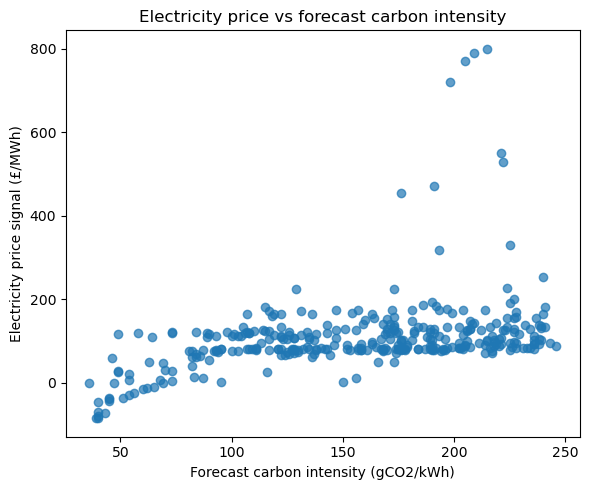

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(
    df_model_full["forecast_gco2_per_kwh"],
    df_model_full["price_gbp_per_mwh"],
    alpha=0.7
)

plt.xlabel("Forecast carbon intensity (gCO2/kWh)")
plt.ylabel("Electricity price signal (£/MWh)")
plt.title("Electricity price vs forecast carbon intensity")
plt.tight_layout()
plt.show()